<a href="https://colab.research.google.com/github/hellohi900/Concept_and_technology_of_AI/blob/main/2510329_risab_rai_Classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/PRSA_data_2010.1.1-2014.12.31.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


Data Cleaning

In [ ]:
df = df.dropna()
df = df.drop(columns=['No'])

In [ ]:
df['date'] = pd.to_datetime(df[['year','month','day','hour']])

In [ ]:
df = df.sort_values('date')

EDA (Stronger Than Baseline)

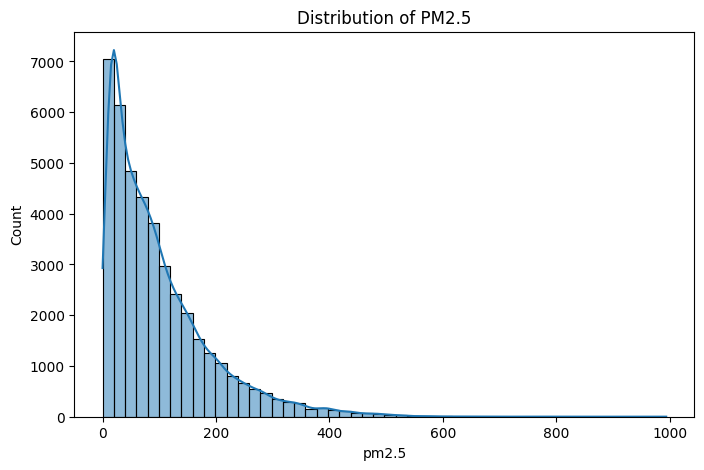

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['pm2.5'], bins=50, kde=True)
plt.title("Distribution of PM2.5")
plt.show()

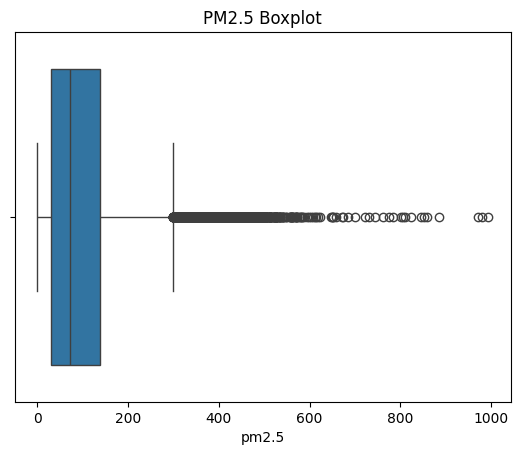

In [ ]:
sns.boxplot(x=df['pm2.5'])
plt.title("PM2.5 Boxplot")
plt.show()

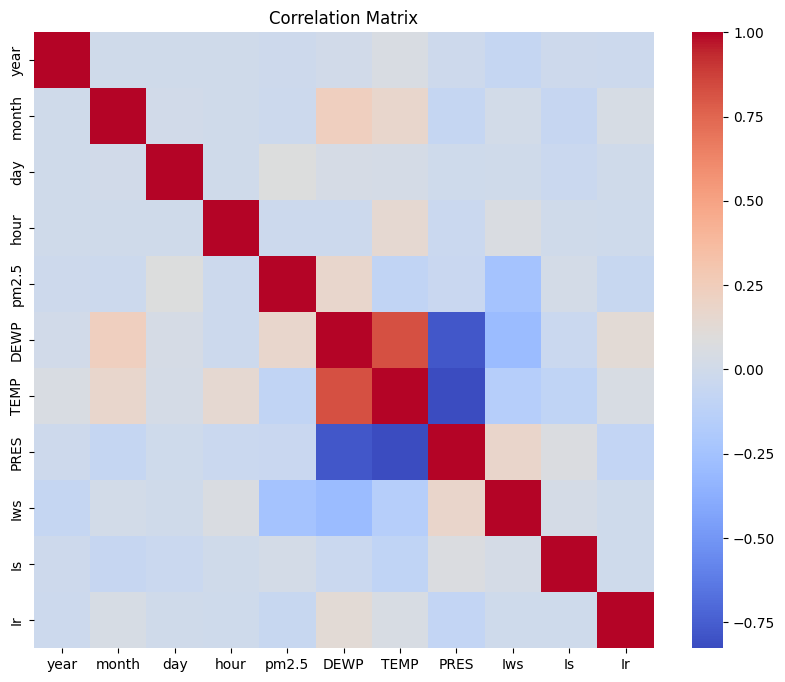

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


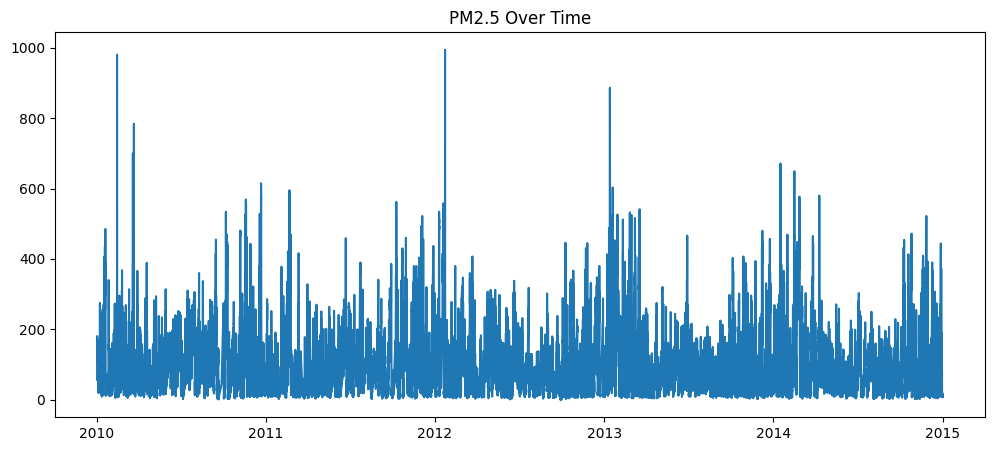

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['pm2.5'])
plt.title("PM2.5 Over Time")
plt.show()

Create Classification Target (Improved)

In [ ]:
def classify_pm25(x):
    if x <= 35:
        return 0  # Good
    elif x <= 75:
        return 1  # Moderate
    else:
        return 2  # Unhealthy

df['air_quality'] = df['pm2.5'].apply(classify_pm25)

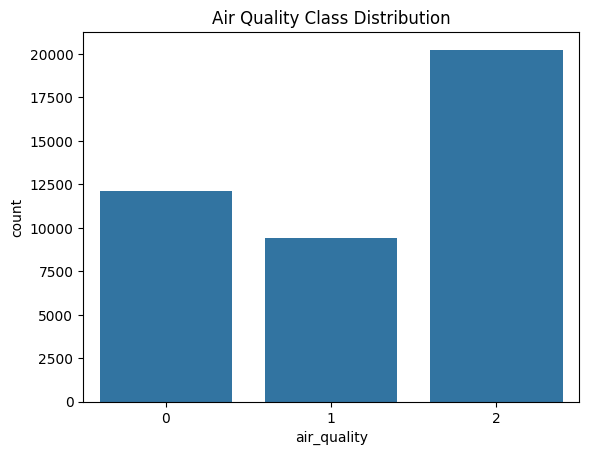

In [ ]:
sns.countplot(x=df['air_quality'])
plt.title("Air Quality Class Distribution")
plt.show()

Feature & Target Separation

In [ ]:
X = df.drop(columns=['pm2.5','air_quality','date'])
y = df['air_quality']

Proper Encoding (Better than .cat.codes)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

Train-Test Split (Time-aware option)

In [ ]:
split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

Scaling (Missing in Baseline)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL 1 — Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    solver='saga',     # better for large feature space
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Accuracy: 0.5723180076628352
              precision    recall  f1-score   support

           0       0.65      0.64      0.64      2452
           1       0.34      0.50      0.40      1906
           2       0.72      0.57      0.63      3994

    accuracy                           0.57      8352
   macro avg       0.57      0.57      0.56      8352
weighted avg       0.61      0.57      0.58      8352



MODEL 2 — Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.6676245210727969
              precision    recall  f1-score   support

           0       0.78      0.65      0.71      2452
           1       0.41      0.25      0.31      1906
           2       0.68      0.88      0.76      3994

    accuracy                           0.67      8352
   macro avg       0.63      0.59      0.60      8352
weighted avg       0.65      0.67      0.65      8352



MODEL 3 — Neural Network

In [ ]:
nn = MLPClassifier(hidden_layer_sizes=(64,32),
                   activation='relu',
                   max_iter=300,
                   random_state=42)

nn.fit(X_train, y_train)

y_pred_nn = nn.predict(X_test)

print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

NN Accuracy: 0.616977969348659
              precision    recall  f1-score   support

           0       0.83      0.40      0.54      2452
           1       0.34      0.43      0.38      1906
           2       0.71      0.84      0.77      3994

    accuracy                           0.62      8352
   macro avg       0.63      0.56      0.56      8352
weighted avg       0.66      0.62      0.61      8352



Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'max_depth': 10, 'n_estimators': 200}
Best CV Score: 0.6066756473581799


Feature Selection

In [ ]:
selector = SelectFromModel(rf, threshold='median')

selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)